
# 01. Single Request Walkthrough
**Goal:** Understand the end-to-end flow of a single request through the Artemis Load Balancer using simulated data.


In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:

import sys

import os
import time
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Basic configuration for plots
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Add project root to path
# Assuming we are in artemis_final/notebooks/load_balancer/
current_dir = Path(os.getcwd())
project_root = current_dir.parent.parent.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
    print(f"Added {project_root} to path")

from artemis_final.load_balancer.public_api import (
    ArtemisLoadBalancer,
    ModelCapacityConfig,
    GlobalSLAConfig,
    StatsRegistry,
    RouterOutput,
    SchedulingContext,
    ModelStateManager,
)



## 1. Setup: Synthetic Statistics
We'll manually populate a `StatsRegistry` with some known values to control the experiment.
- **Model A (Fast, Expensive)**: 100ms, $0.01, Acc 0.85
- **Model B (Slow, Cheap)**: 500ms, $0.001, Acc 0.80
- **Model C (Best, Moderate)**: 300ms, $0.005, Acc 0.95


In [8]:

# 1. Create Registry and Pre-fill Stats
stats_registry = StatsRegistry()

task_type = "vqa"

# Define synthetic stats
# (avg_latency_ms, avg_accuracy, cost_usd)
model_stats = {
    "model_a": (100.0, 0.85, 0.01),
    "model_b": (500.0, 0.80, 0.001),
    "model_c": (300.0, 0.95, 0.005),
}

for model, (lat, acc, cost) in model_stats.items():
    stats_registry.update_latency(task_type, model, lat)
    stats_registry.update_accuracy(task_type, model, acc)
    stats_registry.update_cost(task_type, model, cost)

    print("✅ Stats initialized manually.")


✅ Stats initialized manually.
✅ Stats initialized manually.
✅ Stats initialized manually.



## 2. Setup: Load Balancer
We initialize the LB with a `capacity_aware` mode and a latency SLA.


In [15]:

# 2. Configure and Init Load Balancer
model_configs = {
    "model_a": ModelCapacityConfig(model_name="model_a", base_latency_ms=100.0, max_qps_per_replica=10.0, min_replicas=2, max_replicas=2),
    "model_b": ModelCapacityConfig(model_name="model_b", base_latency_ms=500.0, max_qps_per_replica=5.0, min_replicas=1, max_replicas=1),
    "model_c": ModelCapacityConfig(model_name="model_c", base_latency_ms=300.0, max_qps_per_replica=8.0, min_replicas=2, max_replicas=2),
}

latency_sla_ms = {
    "default": 1000.0,
    "vqa": 400.0  # Strict SLA for VQA
}

lb = ArtemisLoadBalancer(
    model_configs=model_configs,
    stats_registry=stats_registry,
    latency_sla_ms=latency_sla_ms,
    scheduling_mode="capacity_aware", # Try changing to "fast", "cheap", "accuracy"
    router_confidence_threshold=0.6,
    top_k=3,
    simulation_only=True # True means we simulate time but don't need real API calls
)

print(f"✅ Load Balancer ready in mode: {lb.scheduling_mode}")


✅ Load Balancer ready in mode: capacity_aware



## 3. Create a Synthetic Request
We simulate a router output where the router prefers **Model C** (high accuracy) but gives it a moderate probability.


In [16]:
# 3. Create Router Output
router_output = RouterOutput(
    router_probs={"model_a": 0.2, "model_b": 0.1, "model_c": 0.7},
    preferred_model="model_c",
    max_prob=0.7,
    sample_id="test_sample_001",
    task_type="vqa",
)

context = SchedulingContext(
    arrival_ts_ms=time.time() * 1000,
    # sample_id="test_sample_001",
    metadata="vqa",
    load_profile="simulated"
)

print(f"📩 Request: Preferred={router_output.preferred_model}, MaxProb={router_output.max_prob}")


📩 Request: Preferred=model_c, MaxProb=0.7



## 4. Schedule & Inspection
We call `schedule()` and inspect the decision.


In [17]:

# 4. Schedule
decision = lb.schedule(router_output, context)

print("="*40)
print(f"🎯 Decision: {decision.chosen_model}")
print("="*40)
print(f"Est. Total Latency: {decision.total_latency_ms:.1f} ms")
print(f"   (Queue: {decision.queue_delay_ms:.1f} ms, Service: {decision.service_time_ms:.1f} ms)")
print(f"Est. Cost:          ${decision.est_cost_usd:.5f}")
print(f"Est. Accuracy:      {decision.est_accuracy:.3f}")
print(f"SLA Violated?       {decision.sla_violated}")


🎯 Decision: model_c
Est. Total Latency: 300.0 ms
   (Queue: 0.0 ms, Service: 300.0 ms)
Est. Cost:          $0.00500
Est. Accuracy:      0.950
SLA Violated?       False



## 5. Visualizing the Decision Space
Let's see why it made that choice by looking at the candidates properties.


,Model,Total Latency,Accuracy,Cost,Router Prob,Chosen
0,model_a,100.0,0.85,0.010,0.2,False
1,model_b,500.0,0.80,0.001,0.1,False
2,model_c,300.0,0.95,0.005,0.7,True


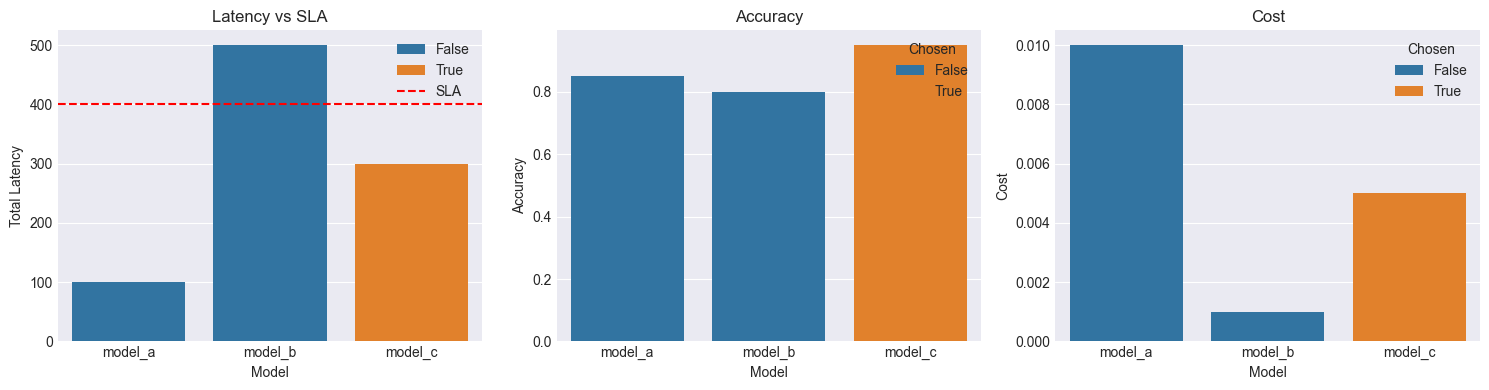

In [18]:

# Extract candidates data for plotting
candidates_data = []
for model in model_stats.keys():
    # Helper to peek at estimated latency logic (approximation)
    # In reality, this logic is inside the scheduling method, but we can recreate it for viz
    state = lb.model_state.get_state(model)
    service_time = stats_registry.estimate_service_time_ms(task_type, model)
    queue_delay = state.estimate_queue_delay(time.time())
    
    candidates_data.append({
        "Model": model,
        "Total Latency": service_time + queue_delay,
        "Accuracy": stats_registry.estimate_accuracy(task_type, model),
        "Cost": stats_registry.estimate_cost_usd(task_type, model),
        "Router Prob": router_output.router_probs.get(model, 0.0),
        "Chosen": (model == decision.chosen_model)
    })

df = pd.DataFrame(candidates_data)
display(df)

# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=df, x="Model", y="Total Latency", hue="Chosen", ax=axes[0])
axes[0].axhline(y=latency_sla_ms["vqa"], color='r', linestyle='--', label='SLA')
axes[0].set_title("Latency vs SLA")
axes[0].legend()

sns.barplot(data=df, x="Model", y="Accuracy", hue="Chosen", ax=axes[1])
axes[1].set_title("Accuracy")

sns.barplot(data=df, x="Model", y="Cost", hue="Chosen", ax=axes[2])
axes[2].set_title("Cost")

plt.tight_layout()
plt.show()
